In [8]:
import pandas as pd

In [9]:
data = pd.read_csv('house_prices.csv')

In [10]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

In [11]:
data.isnull().sum()

Index                     0
Title                     0
Description            3023
Amount(in rupees)         0
Price (in rupees)     17665
location                  0
Carpet Area           80673
Status                  615
Floor                  7077
Transaction              83
Furnishing             2897
facing                70233
overlooking           81436
Society              109678
Bathroom                828
Balcony               48935
Car Parking          103357
Ownership             65517
Super Area           107685
Dimensions           187531
Plot Area            187531
dtype: int64

In [12]:
data = data.drop_duplicates(subset=["Index"])

In [13]:
data['Price (in rupees)'] = data['Price (in rupees)'].fillna(data['Price (in rupees)'].median())
data['Bathroom'] = pd.to_numeric(data['Bathroom'], errors='coerce')
data['Bathroom'] = data['Bathroom'].fillna(data['Bathroom'].median())

In [14]:
data["Balcony"].fillna(data["Balcony"].mode()[0], inplace=True)

C:\Users\mishr\AppData\Local\Temp\ipykernel_21200\3484420442.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data["Balcony"].fillna(data["Balcony"].mode()[0], inplace=True)


0         2
1         2
2         2
3         1
4         2
         ..
187526    3
187527    2
187528    2
187529    2
187530    4
Name: Balcony, Length: 187531, dtype: str

In [15]:
data.isnull().sum()

Index                     0
Title                     0
Description            3023
Amount(in rupees)         0
Price (in rupees)         0
location                  0
Carpet Area           80673
Status                  615
Floor                  7077
Transaction              83
Furnishing             2897
facing                70233
overlooking           81436
Society              109678
Bathroom                  0
Balcony               48935
Car Parking          103357
Ownership             65517
Super Area           107685
Dimensions           187531
Plot Area            187531
dtype: int64

In [16]:
data["Transaction"].fillna(data["Transaction"].mode()[0], inplace=True)
data["Furnishing"].fillna(data["Furnishing"].mode()[0], inplace=True)
data["facing"].fillna("Not specified", inplace=True)  
data["overlooking"].fillna("Not specified", inplace=True)
data["Society"].fillna("Unknown", inplace=True)

C:\Users\mishr\AppData\Local\Temp\ipykernel_21200\1580857101.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data["Transaction"].fillna(data["Transaction"].mode()[0], inplace=True)
C:\Users\mishr\AppData\Local\Temp\ipykernel_21200\1580857101.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series thr

0         Srushti Siddhi Mangal Murti Complex
1                                 Dosti Vihar
2                        Sunrise by Kalpataru
3                                     Unknown
4                 TenX Habitat Raymond Realty
                         ...                 
187526                      Bollywood Esencia
187527                     Sushma Urban Views
187528                      Bollywood Esencia
187529                        Friends Enclave
187530                        Affinity Greens
Name: Society, Length: 187531, dtype: str

In [17]:
data.isnull().sum()

Index                     0
Title                     0
Description            3023
Amount(in rupees)         0
Price (in rupees)         0
location                  0
Carpet Area           80673
Status                  615
Floor                  7077
Transaction              83
Furnishing             2897
facing                70233
overlooking           81436
Society              109678
Bathroom                  0
Balcony               48935
Car Parking          103357
Ownership             65517
Super Area           107685
Dimensions           187531
Plot Area            187531
dtype: int64

In [18]:
data["Carpet Area"] = (data["Carpet Area"].str.replace('sqft', '', regex=False))
data["Carpet Area"] = pd.to_numeric(data["Carpet Area"], errors='coerce')

----------------------------------------------------------------------------------------------------

#Dataset Splitting (for MERGE demo)

In [19]:
data_basic = data[["Index", "Title", "location","Status", "Transaction"]]
data_price = data[["Index", "Price (in rupees)", "Carpet Area"]]
data_features = data[["Index", "Bathroom", "Balcony", "Furnishing"]]

In [20]:
print(data_basic.head())

   Index                                              Title location  \
0      0  1 BHK Ready to Occupy Flat for sale in Srushti...    thane   
1      1  2 BHK Ready to Occupy Flat for sale in Dosti V...    thane   
2      2  2 BHK Ready to Occupy Flat for sale in Sunrise...    thane   
3      3        1 BHK Ready to Occupy Flat for sale Kasheli    thane   
4      4  2 BHK Ready to Occupy Flat for sale in TenX Ha...    thane   

          Status Transaction  
0  Ready to Move      Resale  
1  Ready to Move      Resale  
2  Ready to Move      Resale  
3  Ready to Move      Resale  
4  Ready to Move      Resale  


In [21]:
print(data_price.head())

   Index  Price (in rupees)  Carpet Area
0      0             6000.0        500.0
1      1            13799.0        473.0
2      2            17500.0        779.0
3      3             6034.0        530.0
4      4            18824.0        635.0


In [22]:
print(data_features.head())

   Index  Bathroom Balcony      Furnishing
0      0       1.0       2     Unfurnished
1      1       2.0     NaN  Semi-Furnished
2      2       2.0     NaN     Unfurnished
3      3       1.0       1     Unfurnished
4      4       2.0     NaN     Unfurnished


MERGING Datasets

In [23]:
# Merging the datasets based on 'Index'
merged_data = pd.merge(data_basic, data_price, on="Index") 
merged_data = pd.merge(merged_data, data_features, on="Index")

In [24]:
print(merged_data.head())

   Index                                              Title location  \
0      0  1 BHK Ready to Occupy Flat for sale in Srushti...    thane   
1      1  2 BHK Ready to Occupy Flat for sale in Dosti V...    thane   
2      2  2 BHK Ready to Occupy Flat for sale in Sunrise...    thane   
3      3        1 BHK Ready to Occupy Flat for sale Kasheli    thane   
4      4  2 BHK Ready to Occupy Flat for sale in TenX Ha...    thane   

          Status Transaction  Price (in rupees)  Carpet Area  Bathroom  \
0  Ready to Move      Resale             6000.0        500.0       1.0   
1  Ready to Move      Resale            13799.0        473.0       2.0   
2  Ready to Move      Resale            17500.0        779.0       2.0   
3  Ready to Move      Resale             6034.0        530.0       1.0   
4  Ready to Move      Resale            18824.0        635.0       2.0   

  Balcony      Furnishing  
0       2     Unfurnished  
1     NaN  Semi-Furnished  
2     NaN     Unfurnished  
3       1 

# Filtering

In [25]:
filtered_data = merged_data[(merged_data["Price (in rupees)"] > 5000000) &
                            (merged_data["Bathroom"] >= 2) 
]

In [26]:
print(filtered_data.head())

         Index                                              Title  location  \
181234  181234  3 BHK Ready to Occupy Flat for sale in Nest Ha...  vadodara   

               Status   Transaction  Price (in rupees)  Carpet Area  Bathroom  \
181234  Ready to Move  New Property          6700000.0       1252.0       3.0   

       Balcony   Furnishing  
181234       5  Unfurnished  


In [27]:
merged_data.groupby("location")["Price (in rupees)"].median()

location
agra             3686.5
ahmadnagar       4015.0
ahmedabad        5185.0
allahabad        6034.0
aurangabad       4351.0
                  ...  
varanasi         5057.5
vijayawada       4102.0
visakhapatnam    4717.0
vrindavan        5179.5
zirakpur         4045.5
Name: Price (in rupees), Length: 81, dtype: float64

# Pivot table
pivot table is

In [28]:
pivot_table = merged_data.pivot_table(values="Price (in rupees)",
                                      index="location",
                                      columns="Transaction",
                                      aggfunc="median"
)                            

# Melt (Reshaping)

In [29]:
# it reshapes the data by converting row into columns and columns into rows, making it easier to analyze and visualize the data based on specific variables.
melted_data = pd.melt(merged_data, id_vars=["Index"], value_vars=["Bathroom", "Balcony"],)

In [30]:
print(melted_data.head())

   Index  variable value
0      0  Bathroom   1.0
1      1  Bathroom   2.0
2      2  Bathroom   2.0
3      3  Bathroom   1.0
4      4  Bathroom   2.0


In [31]:
corr_features = [
    "Price (in rupees)",
    "Bathroom",
    "Balcony",
    "Carpet Area"
]

corr_data = data[corr_features].apply(pd.to_numeric, errors='coerce')
corr_matrix = corr_data.corr()

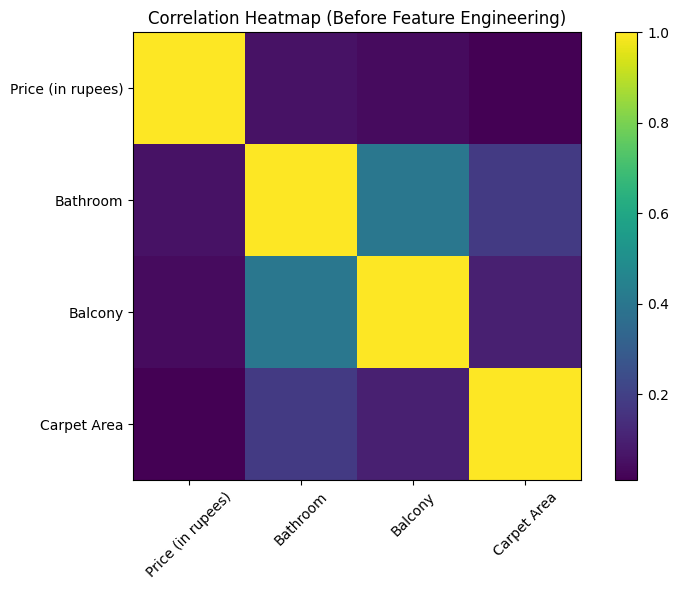

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix)
plt.colorbar()

plt.xticks(range(len(corr_features)), corr_features, rotation=45)
plt.yticks(range(len(corr_features)), corr_features)

plt.title("Correlation Heatmap (Before Feature Engineering)")
plt.tight_layout()
plt.show()

In [33]:
data["Price_per_sqft"] = data["Price (in rupees)"] / data["Carpet Area"]

In [34]:
data.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area,Price_per_sqft
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500.0,Ready to Move,10 out of 11,Resale,...,NaN,Srushti Siddhi Mangal Murti Complex,1.0,2,NaN,NaN,NaN,NaN,NaN,12.000000
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473.0,Ready to Move,3 out of 22,Resale,...,Garden/Park,Dosti Vihar,2.0,NaN,1 Open,Freehold,NaN,NaN,NaN,29.173362
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779.0,Ready to Move,10 out of 29,Resale,...,Garden/Park,Sunrise by Kalpataru,2.0,NaN,1 Covered,Freehold,NaN,NaN,NaN,22.464698
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,6034.0,thane,530.0,Ready to Move,1 out of 3,Resale,...,NaN,NaN,1.0,1,NaN,NaN,NaN,NaN,NaN,11.384906
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635.0,Ready to Move,20 out of 42,Resale,...,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2.0,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN,29.644094


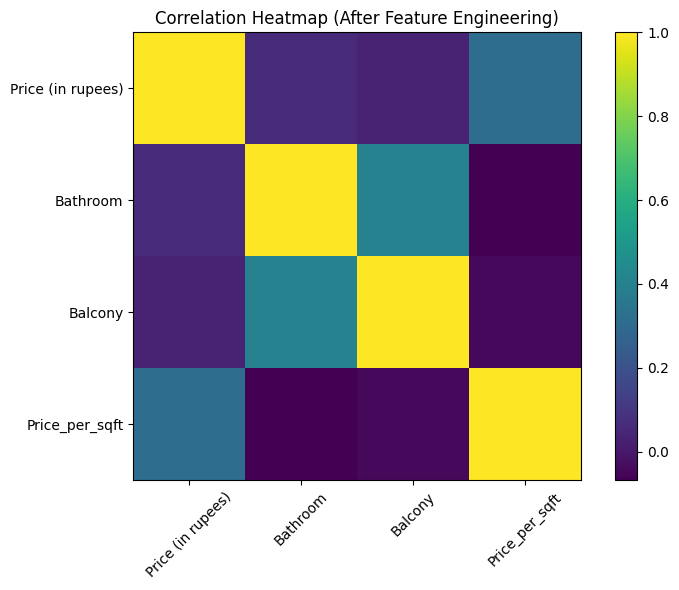

In [35]:
new_corr_features = [
    "Price (in rupees)",
    "Bathroom",
    "Balcony",
    "Price_per_sqft"
]

data['Balcony'] = pd.to_numeric(data['Balcony'], errors='coerce')

new_corr = data[new_corr_features].corr()

plt.figure(figsize=(8, 6))
plt.imshow(new_corr)
plt.colorbar()

plt.xticks(range(len(new_corr_features)), new_corr_features, rotation=45)
plt.yticks(range(len(new_corr_features)), new_corr_features)

plt.title("Correlation Heatmap (After Feature Engineering)")
plt.tight_layout()
plt.show() 

In [36]:
merged_data = pd.get_dummies(merged_data, columns=["Furnishing", "Transaction"], drop_first=True)

In [37]:
print(merged_data.head)

<bound method NDFrame.head of          Index                                              Title  location  \
0            0  1 BHK Ready to Occupy Flat for sale in Srushti...     thane   
1            1  2 BHK Ready to Occupy Flat for sale in Dosti V...     thane   
2            2  2 BHK Ready to Occupy Flat for sale in Sunrise...     thane   
3            3        1 BHK Ready to Occupy Flat for sale Kasheli     thane   
4            4  2 BHK Ready to Occupy Flat for sale in TenX Ha...     thane   
...        ...                                                ...       ...   
187526  187526  3 BHK Ready to Occupy Flat for sale in Bollywo...  zirakpur   
187527  187527  3 BHK Ready to Occupy Flat for sale in Sushma ...  zirakpur   
187528  187528  3 BHK Ready to Occupy Flat for sale in Bollywo...  zirakpur   
187529  187529  2 BHK Ready to Occupy Flat for sale in Friends...  zirakpur   
187530  187530  3 BHK Ready to Occupy Flat for sale in Affinit...  zirakpur   

               Status

In [38]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
merged_data[["Price (in rupees)", "Bathroom"]] = scaler.fit_transform(merged_data[["Price (in rupees)", "Bathroom"]])



In [39]:
print(merged_data.head())

   Index                                              Title location  \
0      0  1 BHK Ready to Occupy Flat for sale in Srushti...    thane   
1      1  2 BHK Ready to Occupy Flat for sale in Dosti V...    thane   
2      2  2 BHK Ready to Occupy Flat for sale in Sunrise...    thane   
3      3        1 BHK Ready to Occupy Flat for sale Kasheli    thane   
4      4  2 BHK Ready to Occupy Flat for sale in TenX Ha...    thane   

          Status  Price (in rupees)  Carpet Area  Bathroom Balcony  \
0  Ready to Move           0.000896        500.0  0.000000       2   
1  Ready to Move           0.002060        473.0  0.111111     NaN   
2  Ready to Move           0.002612        779.0  0.111111     NaN   
3  Ready to Move           0.000901        530.0  0.000000       1   
4  Ready to Move           0.002810        635.0  0.111111     NaN   

   Furnishing_Semi-Furnished  Furnishing_Unfurnished  Transaction_Other  \
0                      False                    True              False

In [40]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Ensure 'Carpet Area' is numeric and handle missing values before calculation
merged_data['Carpet Area'] = pd.to_numeric(merged_data['Carpet Area'], errors='coerce')
merged_data['Carpet Area'] = merged_data['Carpet Area'].fillna(merged_data['Carpet Area'].median())

# Ensure 'Balcony' is numeric and handle missing values before calculation
merged_data['Balcony'] = pd.to_numeric(merged_data['Balcony'], errors='coerce')
merged_data['Balcony'] = merged_data['Balcony'].fillna(merged_data['Balcony'].median())

# Calculate Price per sqft on merged_data
merged_data['Price_per_sqft'] = merged_data['Price (in rupees)'] / merged_data['Carpet Area']

# Updated X to include 'Price_per_sqft' and ensure all features are numeric
X = merged_data[["Bathroom", "Balcony", "Price_per_sqft", "Furnishing_Semi-Furnished", "Furnishing_Unfurnished", "Transaction_Other", "Transaction_Rent/Lease", "Transaction_Resale"]]

y = merged_data["Price (in rupees)"]


X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline = Pipeline([
    ("model", RandomForestRegressor(n_estimators=100, random_state=42))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_val)



In [41]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

r2 = r2_score(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
mae = mean_absolute_error(y_val, y_pred)

print(f"XGBoost R-squared: {r2}")
print(f"XGBoost Mean Squared Error: {mse}")
print(f"XGBoost Mean Absolute Error: {mae}")

XGBoost R-squared: 0.21967703050688714
XGBoost Mean Squared Error: 7.919483807563237e-06
XGBoost Mean Absolute Error: 0.0003232017770825826
